In [13]:
# import packages
import numpy as np
import time
from os.path import exists
import matplotlib.pyplot as plt

In [ ]:
from paraparticles.MPDO import MPDO

In [ ]:
# parameters
g = 1
L = 5
N = 4
Na = 2
t_hop = 1.0
W = 0.2
dt = 0.005
T = 20.0
# cutoff = 1e-16
seed = 42
rng = np.random.default_rng(seed)
# d = 3
chi = 10000
Nt = int(T/dt)
t_grid = np.linspace(0, T + dt, Nt + 1)


In [16]:
tr_TB = []
ni = np.zeros((L, Nt + 1))

In [17]:
mps_evolve = MPDO(L,N,Na,t_hop,W,dt,T,chi,seed,g)
for j in range(L):
    ni[j][0] = mps_evolve.ni_persite[j]

if exists("py_print.txt"):
    f = open("py_print.txt","w")
    f.write('New run\n')
    f.close
else:
    f = open("py_print.txt","x")
    f.write('New run\n')
    f.close()
for i in range(1, Nt + 1):
    t1 = time.time()
    mps_evolve.sweepU()
    t2 = time.time()
    f = open("py_print.txt","a")
    f.write('Time step = '+str(i)+', time taken = '+str(t2-t1)+' for each step\n')
    #print('Time step = '+str(i)+', time taken = '+str(t2-t1)+' for each step')
    f.close()
    for j in range(L):
        ni[j][i] = mps_evolve.ni_persite[j]
        # print(ni[j,i])
    tr_TB.append(mps_evolve.tr_TEBD)

/var/folders/2w/lw0n043x0qv9lhtp8kpmwd7c0000gn/T/ipykernel_63451/2416398283.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  ni[j][0] = mps_evolve.ni_persite[j]
/var/folders/2w/lw0n043x0qv9lhtp8kpmwd7c0000gn/T/ipykernel_63451/2416398283.py:22: ComplexWarning: Casting complex values to real discards the imaginary part
  ni[j][i] = mps_evolve.ni_persite[j]


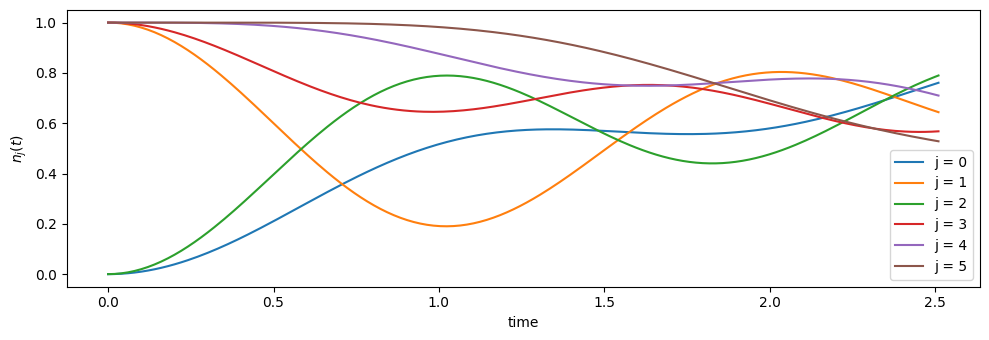

In [18]:
plt.figure(figsize=(10,3.5))
for j in range(L):
    plt.plot(t_grid, ni[j, :], label=f"j = {j}")
plt.xlabel('time')
plt.ylabel(r'$n_j(t)$')
plt.legend()
# plt.yscale("log")
plt.tight_layout()
plt.show()

In [19]:
for j in range(L):
    print(ni[j,0])

-8.326672684688674e-17
0.9999999999999998
-8.326672684688674e-17
0.9999999999999998
1.0
1.0


In [20]:
3**6

729

In [ ]:
# Build full Hamiltonian from the same disorder realization as TEBD
from paraparticles.ED import build_full_H_from_mpo
from paraparticles.Hamiltonian import build_MPO

MPO_ed = build_MPO(L, t_hop, mps_evolve.Omega_list, mps_evolve.q_list, mps_evolve.V_list)
H_ed   = build_full_H_from_mpo(MPO_ed)
E_vals, E_vecs = np.linalg.eigh(H_ed)   # E_vecs[:, k] is eigenstate |k⟩

In [22]:
# Initial state vector in the full 3^L Fock basis
# Basis ordering: |config[0], config[1], ..., config[L-1]⟩
# → linear index = Σ_j config[j] * 3^(L-1-j)
psi0 = np.zeros(3**L, dtype=complex)
idx  = sum(mps_evolve.config[j] * 3**(L - 1 - j) for j in range(L))
psi0[idx] = 1.0

# n_j operators embedded in the full 3^L Hilbert space
I3        = np.eye(3, dtype=complex)
n_loc_mat = np.diag([0., 1., 1.]).astype(complex)

n_ops = []
for j in range(L):
    op = np.array([[1.0 + 0j]])
    for s in range(L):
        op = np.kron(op, n_loc_mat if s == j else I3)
    n_ops.append(op)

In [23]:
# Exact time evolution and measurement of n_j(t)
c_k   = E_vecs.conj().T @ psi0          # ⟨k|ψ₀⟩ for each eigenstate k
ni_ED = np.zeros((L, Nt + 1), dtype=float)

for ti, t in enumerate(t_grid):
    psi_t = E_vecs @ (c_k * np.exp(-1j * E_vals * t))
    for j in range(L):
        ni_ED[j, ti] = np.real(psi_t.conj() @ (n_ops[j] @ psi_t))

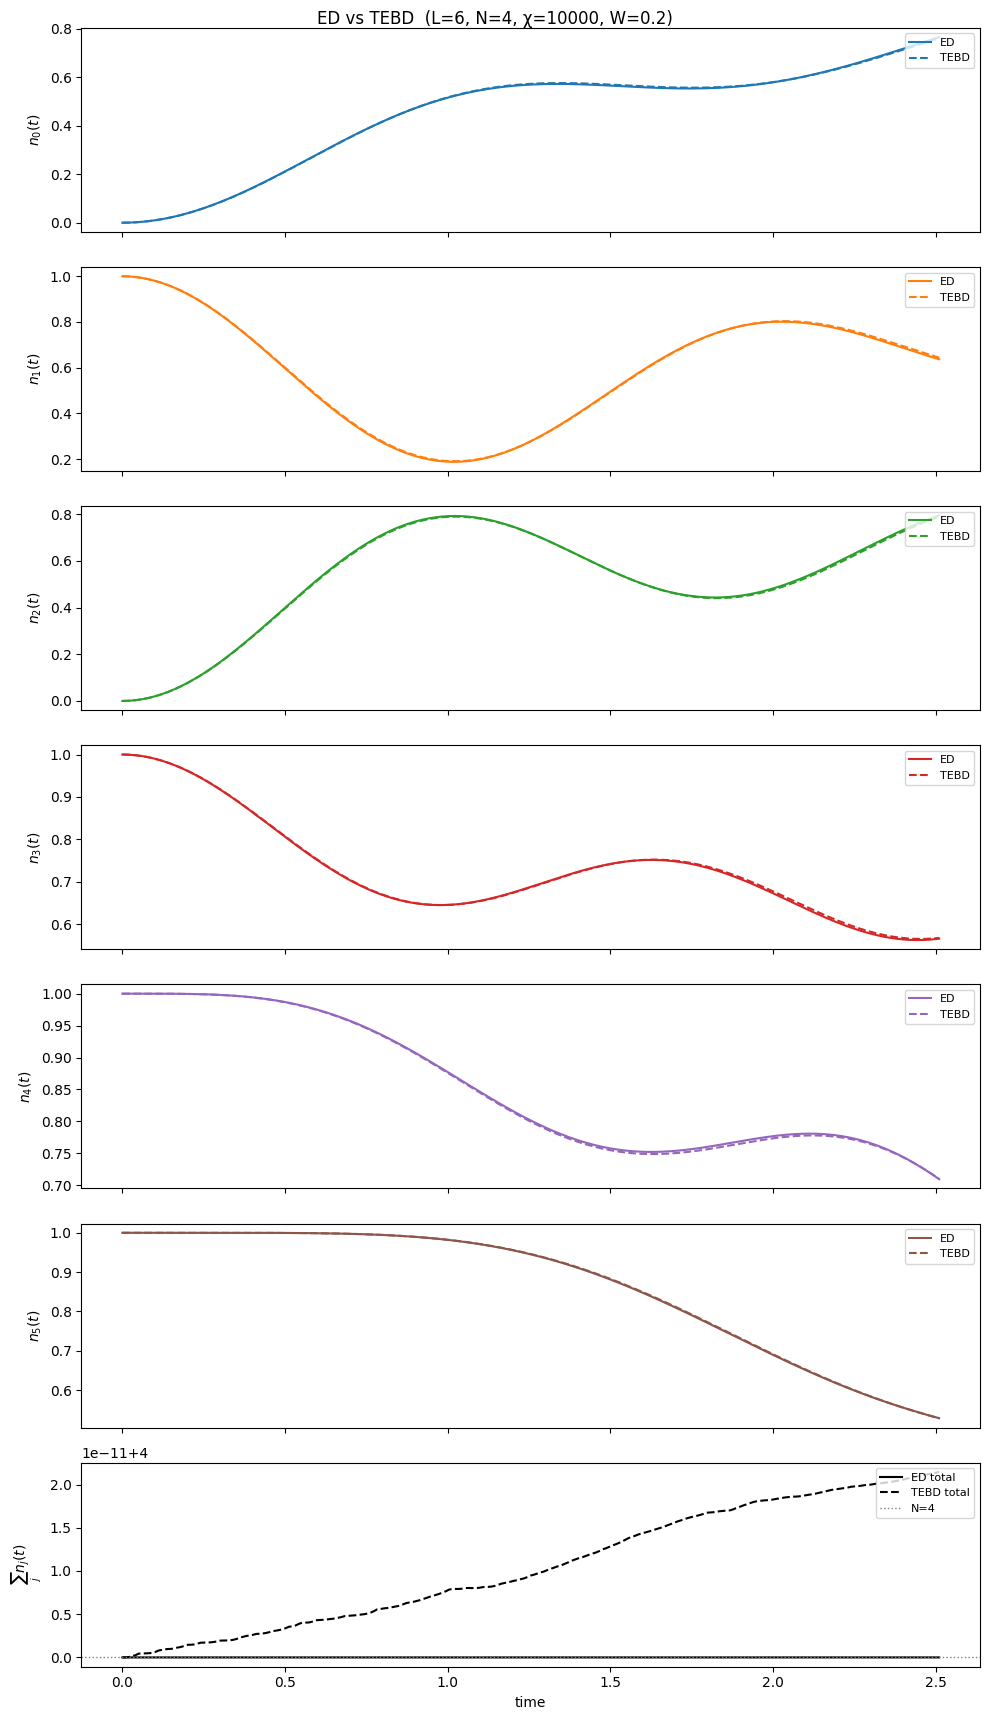

In [24]:
fig, axes = plt.subplots(L + 1, 1, figsize=(10, 2.5 * (L + 1)), sharex=True)

for j in range(L):
    axes[j].plot(t_grid, ni_ED[j, :], '-',  color=f'C{j}', label='ED')
    axes[j].plot(t_grid, ni[j, :],    '--', color=f'C{j}', label='TEBD')
    axes[j].set_ylabel(f'$n_{{{j}}}(t)$')
    axes[j].legend(loc='upper right', fontsize=8)

axes[L].plot(t_grid, np.sum(ni_ED, axis=0), '-k',  label='ED total')
axes[L].plot(t_grid, np.sum(ni,    axis=0), '--k', label='TEBD total')
axes[L].axhline(N, color='gray', linestyle=':', linewidth=1, label=f'N={N}')
axes[L].set_ylabel(r'$\sum_j n_j(t)$')
axes[L].set_xlabel('time')
axes[L].legend(loc='upper right', fontsize=8)

plt.suptitle(f'ED vs TEBD  (L={L}, N={N}, χ={chi}, W={W})', fontsize=12)
plt.tight_layout()
plt.show()